# Credit Card Fraud Detection
**End-to-end imbalanced classification with experiment tracking, explainability and drift monitoring**

This project uses the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (European cardholders, September 2013) to identify fraudulent transactions. Because fraud cases are rare, model evaluation focuses on how well the model identifies fraud while controlling false alarms:

- A **false negative** means a fraudulent transaction goes undetected, causing a direct financial loss.
- A **false positive** means a legitimate transaction is flagged, costing investigation time and inconveniencing the customer.

I compare models using metrics suited to this trade-off and track every experiment with MLflow.

| Section | Contents |
|---|---|
| 1. Setup | Libraries, configuration, MLflow tracking |
| 2. Data and EDA | Data quality, class imbalance, feature associations |
| 3. Build and evaluate models | Preprocessing, four baseline models, comparison, model selection and stress test |
| 4. Class imbalance and improvement | SMOTE before/after, decision threshold, final test evaluation, SHAP explanations |
| 5. Drift and monitoring readiness | Evidently drift reports, drift in a fraud context, monitoring signals |
| 6. Summary | Key findings and links to the Model Card and README |

## 1. Setup

In [ ]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("reports"); REPORT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

EXPERIMENT = "credit-card-fraud-detection"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=Path("mlartifacts").resolve().as_uri())
mlflow.set_experiment(EXPERIMENT)
mlflow.autolog(disable=True)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

2026/09/26 15:58:28 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /usr/local/lib/python3.11/dist-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


2026/09/26 15:58:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/26 15:58:28 INFO mlflow.store.db.utils: Updating database tables


MLflow tracking URI: sqlite:///mlflow.db


## 2. Data and Exploratory Analysis

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
print("Shape (rows, columns):", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", int(df.isna().sum().sum()))
display(df.dtypes.value_counts().to_frame("columns by dtype"))
display(df[["Time", "Amount", "Class"]].describe())

Shape (rows, columns): (284807, 31)


Duplicate rows: 1081
Total missing values: 0


,columns by dtype
float64,30
int64,1


,Time,Amount,Class
count,"284,807.0000","284,807.0000","284,807.0000"
mean,"94,813.8596",88.3496,0.0017
std,"47,488.1460",250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,"54,201.5000",5.6000,0.0000
50%,"84,692.0000",22.0000,0.0000
75%,"139,320.5000",77.1650,0.0000
max,"172,792.0000","25,691.1600",1.0000


,count,percent
Class,,
Legitimate,284315,99.8273
Fraud,492,0.1727


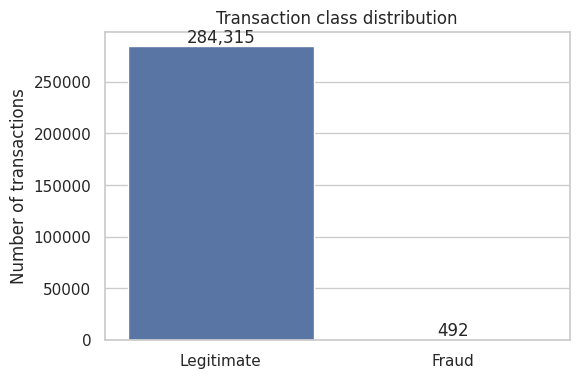

Fraud rate: 0.1727%
Accuracy if every transaction is predicted legitimate: 99.8273%


In [4]:
class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

display(
    class_counts.to_frame("count")
    .assign(percent=class_percent.round(4))
    .rename(index={0: "Legitimate", 1: "Fraud"})
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Legitimate", "Fraud"], y=class_counts.values, ax=ax)
ax.set(title="Transaction class distribution", ylabel="Number of transactions")
for i, count in enumerate(class_counts.values):
    ax.text(i, count, f"{count:,}", ha="center", va="bottom")
plt.show()

print(f"Fraud rate: {class_percent.loc[1]:.4f}%")
print(f"Accuracy if every transaction is predicted legitimate: {class_percent.loc[0]:.4f}%")

### Class imbalance and evaluation
Fraud accounts for approximately **0.1727%** of transactions (492 of 284,807). A model that predicts every transaction as legitimate would still achieve approximately **99.83% accuracy** while identifying no fraud. Accuracy alone therefore hides the model's failure on the class I care about. I instead assess fraud **recall**, **precision**, **F1**, **AUC-ROC** and **average precision** (area under the precision-recall curve), and examine the trade-off between missed fraud and false alarms.

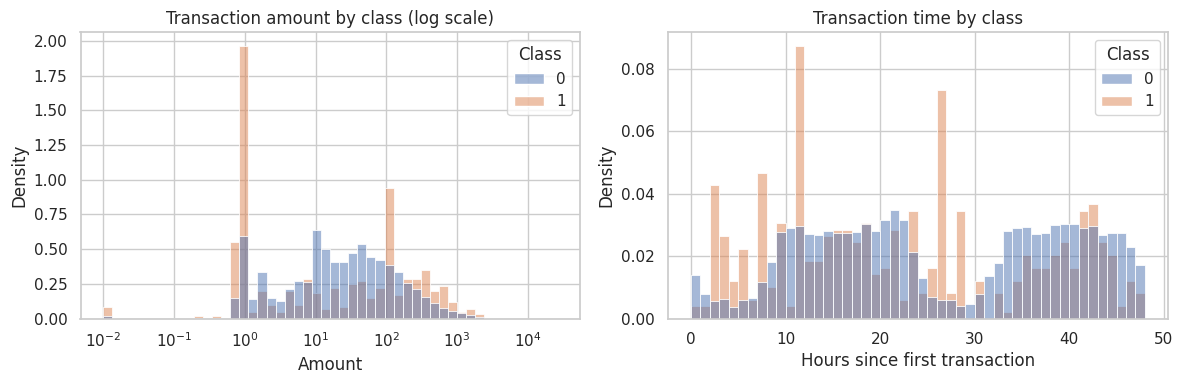

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Legitimate,"284,315.0000",88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,"25,691.1600"
Fraud,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,"2,125.8700"


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="Amount", hue="Class", stat="density", common_norm=False,
             log_scale=(True, False), bins=50, ax=axes[0])
axes[0].set(title="Transaction amount by class (log scale)")
sns.histplot(data=df, x=df["Time"] / 3600, hue="Class", stat="density", common_norm=False,
             bins=48, ax=axes[1])
axes[1].set(title="Transaction time by class", xlabel="Hours since first transaction")
plt.tight_layout(); plt.show()

display(df.groupby("Class")["Amount"].describe().rename(index={0: "Legitimate", 1: "Fraud"}))

Top features by absolute correlation with Class:


,corr_with_class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549


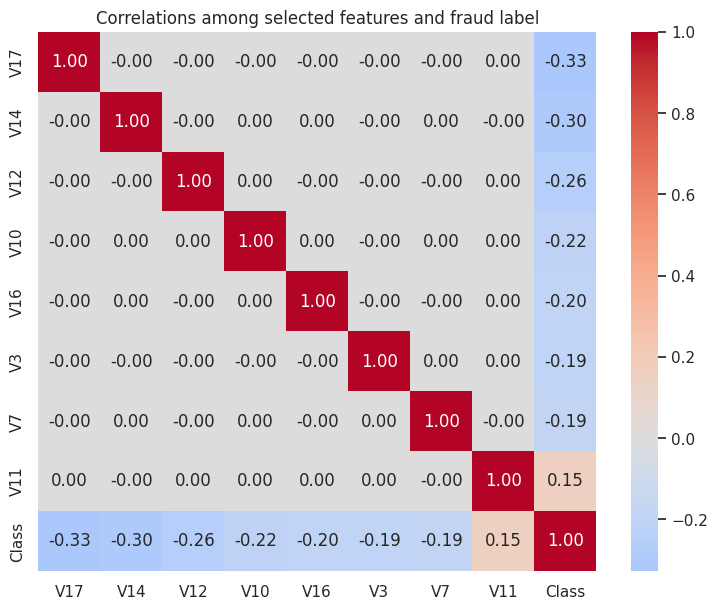

In [6]:
correlations = df.corr(numeric_only=True)["Class"].drop("Class")
top_features = correlations.abs().nlargest(8).index.tolist()

print("Top features by absolute correlation with Class:")
display(correlations.loc[top_features].sort_values(key=abs, ascending=False).to_frame("corr_with_class"))

plt.figure(figsize=(9, 7))
sns.heatmap(df[top_features + ["Class"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations among selected features and fraud label")
plt.show()

### PCA features and EDA findings
V1–V28 are anonymised principal components of the original (confidential) transaction features; only `Time` and `Amount` are in their original units. PCA does not use the fraud label, so component order does not tell us which variables predict fraud.

- Fraud represents **0.1727%** of transactions, so evaluation must focus on the fraud class.
- The components with the largest absolute correlation with `Class` are **V17 (−0.326), V14 (−0.303), V12 (−0.261), V10 (−0.217) and V16 (−0.197)**. All are negative: unusually *low* values are associated with fraud.
- Fraudulent transactions are typically small (median about €9 vs €22 for legitimate) but have a long tail, so `Amount` alone does not separate the classes.
- Fraud is spread more evenly across the day, while legitimate volume drops sharply overnight, so time of day carries some signal.
- The data contains no missing values; the 1,081 exact duplicate rows are kept, as repeated identical transactions are plausible in card data.

These are preliminary associations, not proof that those components will improve a model; I test their usefulness on held-out data with fraud-focused metrics, and revisit them with SHAP in Section 4.

## 3. Build and Evaluate Models

### 3.1 Preprocessing and data split
- **Split:** 80% train / 20% test, stratified so both keep the 0.17% fraud rate. The test set is **held back until the very end** and used exactly once.
- **Validation:** the 80% training portion is split again (80/20, stratified) into a *fit* set used for training and a *validation* set used for model comparison, SMOTE comparison and threshold selection.
- **Scaling:** `Time` and `Amount` are standardised with `StandardScaler`. V1–V28 are already PCA-scaled. The scaler sits inside the model pipeline, so it is fitted on training data only and never sees validation or test data (no leakage).

In [7]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)

split_summary = pd.DataFrame({
    "rows": [len(s) for s in (y_fit, y_val, y_test)],
    "fraud_cases": [int(s.sum()) for s in (y_fit, y_val, y_test)],
    "fraud_rate_%": [s.mean() * 100 for s in (y_fit, y_val, y_test)],
}, index=["fit (train)", "validation", "test (held out)"])
display(split_summary)


def make_scaler():
    return ColumnTransformer(
        [("scaled", StandardScaler(), ["Time", "Amount"])],
        remainder="passthrough",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")   # keeps feature names for the models and SHAP


def make_pipeline(model):
    return Pipeline([("scale_time_amount", make_scaler()), ("model", model)])

,rows,fraud_cases,fraud_rate_%
fit (train),182276,315,0.1728
validation,45569,79,0.1734
test (held out),56962,98,0.1720


### 3.2 Train four models on the raw (imbalanced) data
All four models use default-style settings with **no** re-weighting or resampling, so this is a like-for-like baseline.

> **Stability settings for the two boosting models.** With pure default settings both gradient-boosting libraries can diverge on data this imbalanced: leaves that contain only a handful of fraud cases have almost no curvature (hessian), which produces extreme leaf values that compound over boosting rounds. In the first version of this notebook default LightGBM scored a validation AUC-ROC of 0.51 (chance level), and in cross-validation default XGBoost collapsed on one of five folds (recall 0.06). Two standard settings fix this:
> - **LightGBM:** `reg_lambda=1.0`, the same L2 leaf penalty XGBoost applies by default.
> - **XGBoost:** `max_delta_step=1`, which the XGBoost documentation recommends for logistic regression on extremely imbalanced classes.
>
> These are numerical-stability settings applied equally to both boosters, not tuned hyperparameters; neither re-weights or resamples the data.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=200, eval_metric="logloss", tree_method="hist",
                             max_delta_step=1, random_state=SEED, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=200, reg_lambda=1.0, verbosity=-1,
                               random_state=SEED, n_jobs=-1),
}


def evaluate(y_true, proba, threshold=0.5):
    # Fraud-focused metrics at a given decision threshold.
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision": average_precision_score(y_true, proba),
        "tp": int(tp), "fn": int(fn), "fp": int(fp), "tn": int(tn),
    }


def log_run(run_name, pipeline, metrics, params=None, tags=None, figures=None,
            prefix="val_", log_model=True):
    # Log one experiment run to MLflow and return its run id.
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tags({"dataset": "creditcard.csv", **(tags or {})})
        if params:
            mlflow.log_params({k: v for k, v in params.items() if v is not None})
        mlflow.log_metrics({f"{prefix}{k}": float(v) for k, v in metrics.items()})
        for name, fig in (figures or {}).items():
            mlflow.log_figure(fig, name)
        if log_model:
            mlflow.sklearn.log_model(pipeline, name="model", serialization_format="cloudpickle")
    return run.info.run_id

In [9]:
results, fitted_models, val_proba, run_ids = [], {}, {}, {}

for name, estimator in models.items():
    pipeline = make_pipeline(clone(estimator))
    start = time.perf_counter()
    pipeline.fit(X_fit, y_fit)
    fit_seconds = time.perf_counter() - start

    proba = pipeline.predict_proba(X_val)[:, 1]
    metrics = evaluate(y_val, proba)

    run_ids[name] = log_run(
        run_name=f"{name} - baseline",
        pipeline=pipeline,
        metrics={**metrics, "fit_seconds": fit_seconds},
        params={"model_type": name, "resampling": "none", "threshold": 0.5,
                **pipeline.named_steps["model"].get_params()},
        tags={"stage": "step3_baseline"},
    )
    fitted_models[name], val_proba[name] = pipeline, proba
    results.append({"model": name, **metrics, "fit_seconds": fit_seconds})
    print(f"{name:<20} recall={metrics['recall']:.4f}  precision={metrics['precision']:.4f}  "
          f"({fit_seconds:.1f}s)")

2026/09/26 15:58:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression  recall=0.4937  precision=0.8298  (0.5s)


2026/09/26 15:59:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest        recall=0.7089  precision=0.9333  (67.5s)


2026/09/26 15:59:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost              recall=0.7468  precision=0.9365  (2.5s)


2026/09/26 15:59:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM             recall=0.7848  precision=0.8986  (3.3s)


### 3.3 Comparison table (validation set, threshold 0.5)

In [10]:
comparison = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values(["recall", "precision"], ascending=False)
)
metric_cols = ["precision", "recall", "f1", "roc_auc", "average_precision"]
display(
    comparison[metric_cols + ["tp", "fn", "fp"]]
    .style.format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(subset=metric_cols, color="#c6efce")
)
comparison.to_csv(REPORT_DIR / "baseline_model_comparison.csv")

,precision,recall,f1,roc_auc,average_precision,tp,fn,fp
model,,,,,,,,
LightGBM,0.8986,0.7848,0.8378,0.9696,0.8063,62,17,7
XGBoost,0.9365,0.7468,0.8310,0.9683,0.8402,59,20,4
Random Forest,0.9333,0.7089,0.8058,0.9351,0.8207,56,23,4
Logistic Regression,0.8298,0.4937,0.6190,0.9625,0.7079,39,40,8


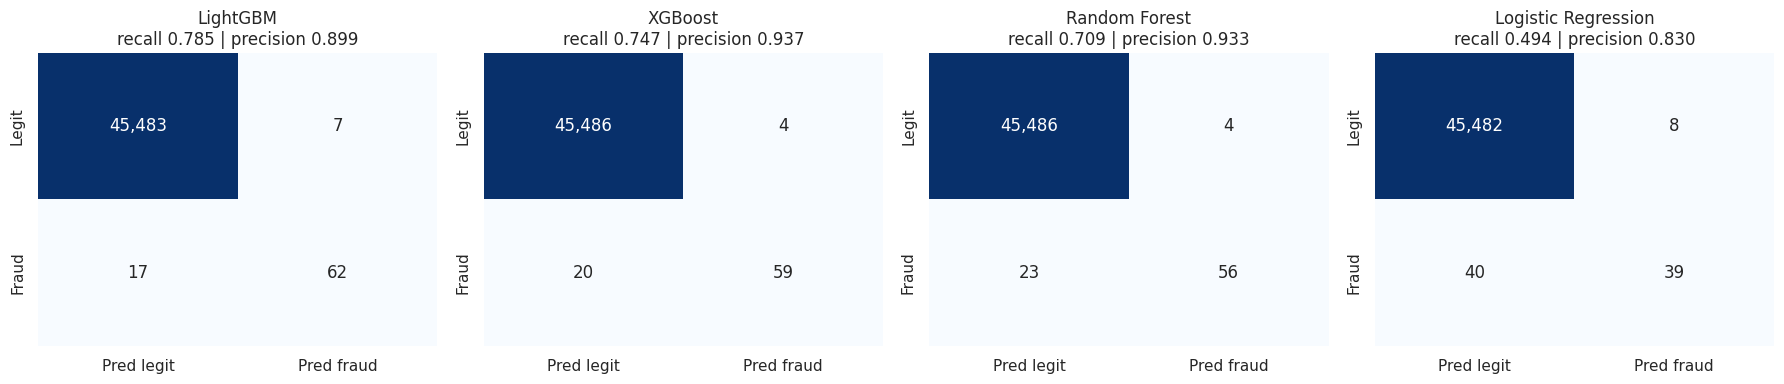

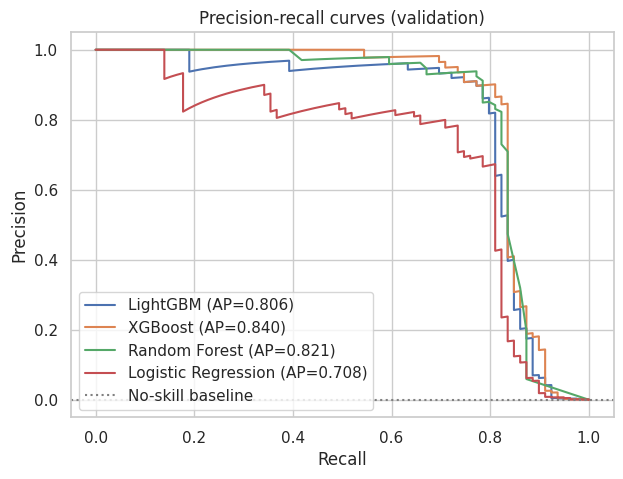

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, comparison.index):
    row = comparison.loc[name]
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]]).astype(int)
    sns.heatmap(cm, annot=True, fmt=",d", cbar=False, cmap="Blues", ax=ax,
                xticklabels=["Pred legit", "Pred fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(f"{name}\nrecall {row.recall:.3f} | precision {row.precision:.3f}")
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name in comparison.index:
    p, r, _ = precision_recall_curve(y_val, val_proba[name])
    ax.plot(r, p, label=f"{name} (AP={comparison.loc[name, 'average_precision']:.3f})")
ax.axhline(y_val.mean(), ls=":", c="grey", label="No-skill baseline")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves (validation)")
ax.legend(loc="lower left")
plt.savefig(FIG_DIR / "baseline_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.4 Model selection: stress-testing the choice
The validation set contains only **79 fraud cases**, so one extra caught fraud moves recall by 1.3 percentage points. A ranking based on that single split could easily be luck. Before committing to a model, the choice was tested in four ways:

1. **Is the recall gap on the validation set real or noise?** A paired bootstrap resamples the validation set 2,000 times and recomputes every model's recall on the same resample.
2. **Does the ranking hold on more data?** 5-fold stratified cross-validation on the full training set (227,845 transactions, **394 fraud cases**) gives out-of-fold predictions for every training transaction, plus the fold-to-fold spread.
3. **What does it cost?** A missed fraud costs the transaction `Amount` (the direct loss). A false alarm costs an assumed **€5** for analyst review and customer friction. I compare total cost at the default 0.5 threshold and at each model's cost-minimising threshold.
4. **Does the conclusion survive a different cost assumption?** I repeat the cost comparison for false-alarm costs from €1 to €50.

In [12]:
# (1) Paired bootstrap of validation recall
rng = np.random.default_rng(SEED)
N_BOOT = 2000
y_val_arr = y_val.to_numpy()
preds = {name: (val_proba[name] >= 0.5).astype(int) for name in comparison.index}

boot = {name: np.empty(N_BOOT) for name in comparison.index}
for b in range(N_BOOT):
    idx = rng.integers(0, len(y_val_arr), len(y_val_arr))
    yb = y_val_arr[idx]
    for name in comparison.index:
        boot[name][b] = (preds[name][idx] & yb).sum() / yb.sum()

leader = comparison.index[0]
boot_summary = pd.DataFrame({
    "val_recall": comparison["recall"],
    "ci_low_95": {n: np.percentile(v, 2.5) for n, v in boot.items()},
    "ci_high_95": {n: np.percentile(v, 97.5) for n, v in boot.items()},
    f"P({leader} recall > model)": {
        n: np.nan if n == leader else (boot[leader] > boot[n]).mean() for n in boot
    },
})
display(boot_summary)

,val_recall,ci_low_95,ci_high_95,P(LightGBM recall > model)
LightGBM,0.7848,0.6875,0.8750,NaN
XGBoost,0.7468,0.6477,0.8434,0.7915
Random Forest,0.7089,0.6076,0.8108,0.9635
Logistic Regression,0.4937,0.3780,0.6053,1.0000


In [13]:
# (2) 5-fold stratified cross-validation on the full training set
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_train_arr = y_train.to_numpy()
amount_train = X_train["Amount"].to_numpy()


def cv_out_of_fold(pipeline):
    # Out-of-fold fraud scores for every training row, plus recall per fold.
    oof = np.zeros(len(y_train))
    fold_recall = []
    for fit_idx, hold_idx in cv.split(X_train, y_train):
        fold_pipe = clone(pipeline).fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        oof[hold_idx] = fold_pipe.predict_proba(X_train.iloc[hold_idx])[:, 1]
        fold_recall.append(recall_score(y_train_arr[hold_idx], oof[hold_idx] >= 0.5))
    return oof, np.array(fold_recall)


oof_proba, cv_rows = {}, []
for name, estimator in models.items():
    start = time.perf_counter()
    oof_proba[name], fold_recall = cv_out_of_fold(make_pipeline(estimator))
    m = evaluate(y_train, oof_proba[name])
    cv_rows.append({"model": name, **m, "fold_recall_min": fold_recall.min(),
                    "fold_recall_max": fold_recall.max(), "cv_seconds": time.perf_counter() - start})
    with mlflow.start_run(run_id=run_ids[name]):       # attach CV results to the baseline run
        mlflow.log_metrics({f"cv_{k}": float(v) for k, v in m.items()})
        mlflow.log_metrics({"cv_fold_recall_min": fold_recall.min(),
                            "cv_fold_recall_max": fold_recall.max()})
    print(f"{name:<20} CV recall={m['recall']:.4f}  folds={np.round(fold_recall, 3)}")

cv_table = pd.DataFrame(cv_rows).set_index("model").sort_values("recall", ascending=False)
display(cv_table[metric_cols + ["fold_recall_min", "fold_recall_max", "tp", "fn", "fp", "cv_seconds"]]
        .style.format("{:.4f}", subset=metric_cols + ["fold_recall_min", "fold_recall_max"])
        .format("{:.0f}", subset=["cv_seconds"])
        .highlight_max(subset=metric_cols, color="#c6efce"))
cv_table.to_csv(REPORT_DIR / "cv_model_comparison.csv")

Logistic Regression  CV recall=0.6421  folds=[0.641 0.608 0.696 0.633 0.633]


Random Forest        CV recall=0.7766  folds=[0.756 0.759 0.759 0.823 0.785]


XGBoost              CV recall=0.7741  folds=[0.795 0.696 0.785 0.823 0.772]


LightGBM             CV recall=0.7868  folds=[0.782 0.759 0.759 0.848 0.785]


,precision,recall,f1,roc_auc,average_precision,fold_recall_min,fold_recall_max,tp,fn,fp,cv_seconds
model,,,,,,,,,,,
LightGBM,0.9226,0.7868,0.8493,0.9844,0.8423,0.7595,0.8481,310,84,26,18
Random Forest,0.9387,0.7766,0.8500,0.9424,0.8388,0.7564,0.8228,306,88,20,346
XGBoost,0.9502,0.7741,0.8531,0.9785,0.8435,0.6962,0.8228,305,89,16,13
Logistic Regression,0.8724,0.6421,0.7398,0.9777,0.7601,0.6076,0.6962,253,141,37,3


In [14]:
# (3) + (4) Business cost of errors, using the out-of-fold predictions
thresholds = np.round(np.arange(0.01, 0.991, 0.01), 2)
FP_COST = 5.0   # assumed cost of one false alarm (analyst review + customer friction), EUR


def business_cost(y_true, proba, amount, threshold, fp_cost=FP_COST):
    # Missed-fraud loss (sum of missed amounts) plus false-alarm review cost.
    flagged = proba >= threshold
    missed = (y_true == 1) & ~flagged
    false_alarm = (y_true == 0) & flagged
    return amount[missed].sum() + fp_cost * false_alarm.sum()


def cost_curve(y_true, proba, amount, fp_cost=FP_COST):
    return np.array([business_cost(y_true, proba, amount, t, fp_cost) for t in thresholds])


cost_rows = []
for name in cv_table.index:
    costs = cost_curve(y_train_arr, oof_proba[name], amount_train)
    best_t = thresholds[costs.argmin()]
    at_best = evaluate(y_train, oof_proba[name], best_t)
    cost_rows.append({"model": name, "cost@0.5": costs[thresholds == 0.5][0],
                      "best_threshold": best_t, "cost@best": costs.min(),
                      "recall@best": at_best["recall"], "precision@best": at_best["precision"],
                      "fn@best": at_best["fn"], "fp@best": at_best["fp"]})
cost_table = pd.DataFrame(cost_rows).set_index("model").sort_values("cost@best")

fraud_exposure = amount_train[y_train_arr == 1].sum()
print(f"Total fraud value in the training set: EUR {fraud_exposure:,.2f}")
display(cost_table.style.format({"cost@0.5": "€{:,.0f}", "cost@best": "€{:,.0f}",
                                 "recall@best": "{:.3f}", "precision@best": "{:.3f}",
                                 "best_threshold": "{:.2f}"}))

sensitivity = pd.DataFrame({
    f"FP cost €{c:g}": {name: cost_curve(y_train_arr, oof_proba[name], amount_train, c).min()
                        for name in cv_table.index}
    for c in [1, 5, 10, 25, 50]
})
print("Minimum achievable cost (out-of-fold) under different false-alarm cost assumptions:")
display(sensitivity.style.format("€{:,.0f}").highlight_min(axis=0, color="#c6efce"))

Total fraud value in the training set: EUR 49,483.04


,cost@0.5,best_threshold,cost@best,recall@best,precision@best,fn@best,fp@best
model,,,,,,,
Random Forest,"€15,309",0.04,"€12,019",0.860,0.424,55,460
XGBoost,"€15,528",0.19,"€12,813",0.810,0.927,75,25
LightGBM,"€13,887",0.11,"€12,931",0.817,0.897,72,37
Logistic Regression,"€21,662",0.03,"€14,059",0.827,0.663,68,166


Minimum achievable cost (out-of-fold) under different false-alarm cost assumptions:


,FP cost €1,FP cost €5,FP cost €10,FP cost €25,FP cost €50
LightGBM,"€12,782","€12,931","€13,116","€13,643","€14,518"
Random Forest,"€10,179","€12,019","€13,182","€14,082","€15,091"
XGBoost,"€12,713","€12,813","€12,938","€13,313","€13,938"
Logistic Regression,"€13,163","€14,059","€14,889","€16,909","€19,411"


### 3.5 Decision: LightGBM, with a documented caveat on cost

**What the evidence says**

| Test | Result | Supports LightGBM? |
|---|---|---|
| Validation recall (79 fraud) | LightGBM **0.785** > XGBoost 0.747 > Random Forest 0.709 > Logistic Regression 0.494 | Yes |
| Bootstrap on validation | 95% interval for LightGBM recall is 0.69–0.88. LightGBM beats XGBoost in only **79%** of resamples (Random Forest in 96%) | Weakly: the lead over XGBoost is not statistically reliable |
| 5-fold CV recall (394 fraud) | LightGBM **0.787** (310 caught) > Random Forest 0.777 (306) > XGBoost 0.774 (305) > Logistic Regression 0.642 | Yes, but the top three are within 5 fraud cases of each other |
| Fold stability | LightGBM 0.76–0.85, Random Forest 0.76–0.82, XGBoost 0.70–0.82 | Yes: no weak fold |
| Cost at the default 0.5 threshold | LightGBM **€13,887** vs Random Forest €15,309, XGBoost €15,528 (total fraud value €49,483) | Yes |
| Cost at each model's best threshold | Random Forest €12,019 < XGBoost €12,813 < LightGBM €12,931 | **No** |
| Cost sensitivity (false alarm €1–€50) | Random Forest cheapest at €1–€5; XGBoost cheapest at €10–€50; LightGBM never cheapest (always within 8% of the best) | **No** |

**Decision.** LightGBM is selected. It has the highest recall on both the validation split and cross-validation, the fewest missed frauds, the lowest cost at the default threshold, stable folds, and it trains about 20× faster than Random Forest (19 s vs 368 s for 5-fold CV), which matters when retraining is frequent (Section 5).

**What the stress test changed.** The original draft of this notebook chose XGBoost on the strength of one extra fraud case on the validation set, while default LightGBM had silently diverged. Stress-testing shows three things:
1. **The top three tree models are statistically tied on recall.** The ranking is driven by 4–5 fraud cases out of 394 and should not be over-sold.
2. **Recall alone is not the business objective.** Once each model is given its own cost-optimal threshold, the ranking flips. Random Forest's cost win at €5 per false alarm comes from a threshold of 0.04 that raises **460 alerts to catch 339 frauds** (precision 0.42), roughly 12× LightGBM's alert volume. That is only viable if the review team has that capacity.
3. **The right model depends on the false-alarm cost, which is an assumption.** If the business confirms that a false alarm costs €10 or more, XGBoost is the cost-optimal choice and should be tested as a challenger (Section 5.3).

**Known weaknesses of this rationale:** the €5 false-alarm cost and "loss = transaction amount" are assumptions; costs ignore chargeback fees and customer churn; hyperparameters were not tuned for any model, so the ranking could change after tuning.

In [15]:
BEST_MODEL = cv_table["recall"].idxmax()   # highest cross-validated recall
print("Selected model:", BEST_MODEL)

Selected model: LightGBM


## 4. Handle Class Imbalance and Improve Performance

### 4.1 SMOTE on the training data only

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic fraud examples by interpolating between real fraud cases and their nearest fraud neighbours. It sits **inside an imbalanced-learn pipeline after the scaler**, so it runs only when the model is fitted. In cross-validation that means only the four training folds are resampled; the held-out fold, the validation set and the test set are never resampled and keep the real 0.17% fraud rate. Resampling *before* splitting would leak synthetic copies of test-set fraud into training and inflate the scores.

The comparison uses the same 5-fold out-of-fold predictions as Section 3.4 (394 fraud cases), so before and after are measured on exactly the same transactions.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("Best model carried forward:", BEST_MODEL)


def make_smote_pipeline(model):
    return ImbPipeline([
        ("scale_time_amount", make_scaler()),
        ("smote", SMOTE(k_neighbors=5, random_state=SEED)),
        ("model", model),
    ])


fit_idx, _ = next(cv.split(X_train, y_train))
_, y_resampled = SMOTE(random_state=SEED).fit_resample(
    make_scaler().fit_transform(X_train.iloc[fit_idx]), y_train.iloc[fit_idx])
display(pd.DataFrame({
    "before SMOTE": y_train.iloc[fit_idx].value_counts().sort_index(),
    "after SMOTE": y_resampled.value_counts().sort_index(),
}).rename(index={0: "Legitimate", 1: "Fraud"}))

start = time.perf_counter()
smote_oof, smote_fold_recall = cv_out_of_fold(make_smote_pipeline(clone(models[BEST_MODEL])))
smote_cv_seconds = time.perf_counter() - start

before = evaluate(y_train, oof_proba[BEST_MODEL])
after = evaluate(y_train, smote_oof)
before_after = pd.DataFrame({"Before SMOTE": before, "After SMOTE": after}).T[metric_cols + ["tp", "fn", "fp"]]
display(before_after)

Best model carried forward: LightGBM


,before SMOTE,after SMOTE
Class,,
Legitimate,181960,181960
Fraud,316,181960


,precision,recall,f1,roc_auc,average_precision,tp,fn,fp
Before SMOTE,0.9226,0.7868,0.8493,0.9844,0.8423,310.0000,84.0000,26.0000
After SMOTE,0.7494,0.8426,0.7933,0.9805,0.8534,332.0000,62.0000,111.0000


### 4.2 Before vs after SMOTE: side-by-side comparison
Both runs are logged to MLflow as child runs of one parent run, so the comparison can be reproduced and viewed side by side in the MLflow UI.

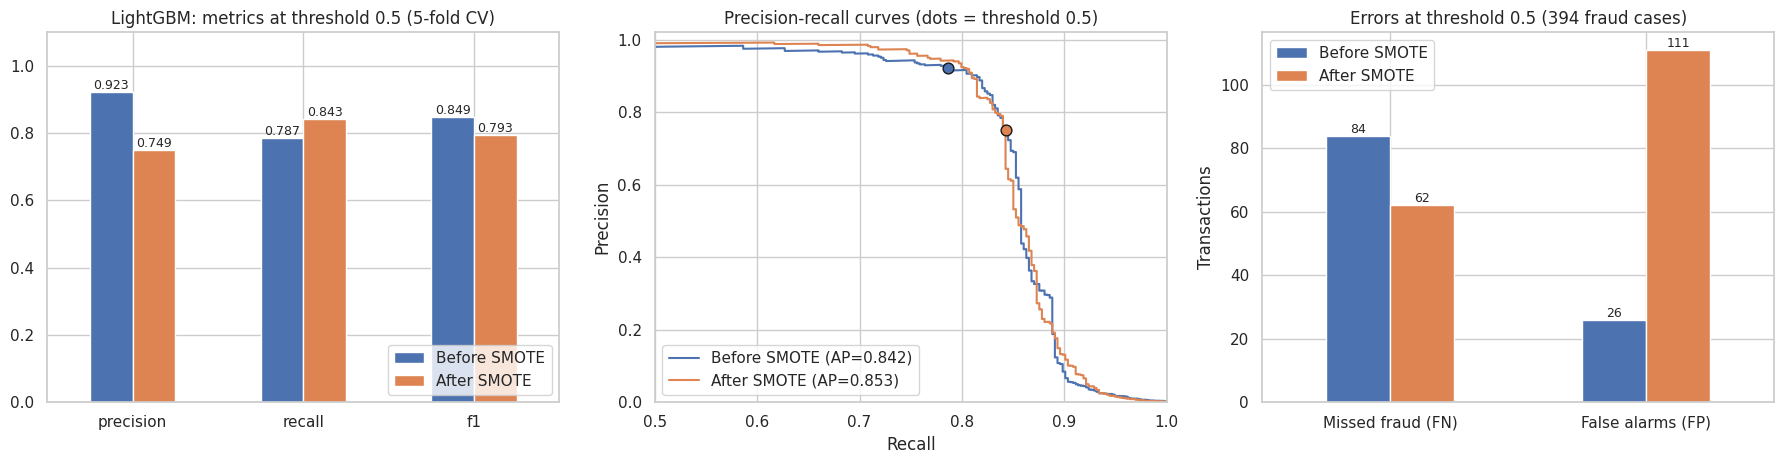

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
colors = {"Before SMOTE": "#4c72b0", "After SMOTE": "#dd8452"}

# (a) Precision / Recall / F1 at threshold 0.5
bar_df = pd.DataFrame({"Before SMOTE": before, "After SMOTE": after}).loc[["precision", "recall", "f1"]]
bar_df.plot.bar(ax=axes[0], rot=0, color=list(colors.values()))
axes[0].set(ylim=(0, 1.1), title=f"{BEST_MODEL}: metrics at threshold 0.5 (5-fold CV)")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=9)
axes[0].legend(loc="lower right")

# (b) Precision-recall curves, with the 0.5 threshold marked
for label, proba in [("Before SMOTE", oof_proba[BEST_MODEL]), ("After SMOTE", smote_oof)]:
    p, r, _ = precision_recall_curve(y_train, proba)
    axes[1].plot(r, p, color=colors[label],
                 label=f"{label} (AP={average_precision_score(y_train, proba):.3f})")
    m = evaluate(y_train, proba)
    axes[1].scatter(m["recall"], m["precision"], color=colors[label], s=60, zorder=3, edgecolor="k")
axes[1].set(xlabel="Recall", ylabel="Precision", xlim=(0.5, 1.0), ylim=(0.0, 1.02),
            title="Precision-recall curves (dots = threshold 0.5)")
axes[1].legend(loc="lower left")

# (c) Missed fraud vs false alarms
counts = pd.DataFrame({"Missed fraud (FN)": [before["fn"], after["fn"]],
                       "False alarms (FP)": [before["fp"], after["fp"]]},
                      index=["Before SMOTE", "After SMOTE"])
counts.T.plot.bar(ax=axes[2], rot=0, color=list(colors.values()))
axes[2].set(title="Errors at threshold 0.5 (394 fraud cases)", ylabel="Transactions")
for container in axes[2].containers:
    axes[2].bar_label(container, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "smote_before_after.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
with mlflow.start_run(run_name=f"{BEST_MODEL} - SMOTE comparison") as parent:
    mlflow.set_tags({"stage": "step4_smote", "model_type": BEST_MODEL, "evaluation": "5-fold CV out-of-fold"})
    mlflow.log_figure(fig, "smote_before_after.png")
    for label, metrics, resampling, fold_recall in [
        ("before SMOTE", before, "none", None),
        ("after SMOTE", after, "SMOTE", smote_fold_recall),
    ]:
        with mlflow.start_run(run_name=f"{BEST_MODEL} - {label}", nested=True):
            mlflow.set_tags({"stage": "step4_smote", "model_type": BEST_MODEL})
            mlflow.log_params({"model_type": BEST_MODEL, "resampling": resampling, "threshold": 0.5,
                               "cv_folds": 5, "smote_k_neighbors": 5 if resampling == "SMOTE" else "n/a",
                               **{k: v for k, v in models[BEST_MODEL].get_params().items() if v is not None}})
            mlflow.log_metrics({f"cv_{k}": float(v) for k, v in metrics.items()})
print("Logged parent run:", parent.info.run_id)

Logged parent run: 90c5327adba74710bbc8750a0dff6902


### 4.3 Interpreting the SMOTE result
At the default 0.5 threshold, SMOTE does what it promises for recall:

| LightGBM, 5-fold CV (394 fraud) | Before SMOTE | After SMOTE | Change |
|---|---|---|---|
| Recall | 0.787 | **0.843** | +22 frauds caught (84 → 62 missed) |
| Precision | **0.923** | 0.749 | false alarms 26 → 111 (4.3×) |
| F1 | **0.849** | 0.793 | |
| Average precision (PR-AUC) | 0.842 | 0.853 | about the same |
| AUC-ROC | 0.984 | 0.981 | about the same |

**Interpretation.** The precision-recall curves (middle chart) almost overlap. SMOTE did **not** make the model much better at *ranking* fraud above legitimate transactions (average precision +0.011). It mainly **moved the operating point** along the same curve: training on 50/50 data inflates every fraud score, so the fixed 0.5 cut-off behaves like a much lower threshold. The same trade-off is available without SMOTE by lowering the threshold, which Section 4.4 does directly.

Other points against SMOTE here: it doubles the training set (slower retraining), its synthetic fraud cases are interpolations in PCA space that may not correspond to realistic transactions, and its scores are no longer calibrated probabilities (a score of 0.8 no longer means an ~80% chance of fraud).

### 4.4 Choosing the decision threshold
A threshold of 0.5 is arbitrary, and SMOTE in particular shifts the whole score distribution upwards. For both variants I pick the threshold that minimises the business cost from Section 3.4 on the **out-of-fold predictions** (394 fraud cases), then keep the cheaper variant. The threshold is fixed before the test set is touched.

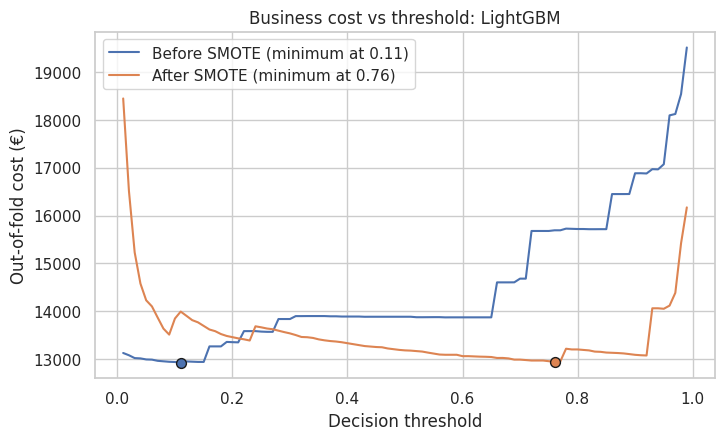

,best_threshold,cv_cost,precision,recall,f1,fn,fp
variant,,,,,,,
Before SMOTE,0.1100,"12,930.9300",0.8969,0.8173,0.8552,72,37
After SMOTE,0.7600,"12,948.8600",0.8394,0.8223,0.8308,70,62


Final model: LightGBM (Before SMOTE), decision threshold = 0.11


In [19]:
candidates = {"Before SMOTE": (make_pipeline, oof_proba[BEST_MODEL]),
              "After SMOTE": (make_smote_pipeline, smote_oof)}

fig, ax = plt.subplots(figsize=(8, 4.5))
threshold_rows = []
for label, (builder, proba) in candidates.items():
    costs = cost_curve(y_train_arr, proba, amount_train)
    best_t = thresholds[costs.argmin()]
    ax.plot(thresholds, costs, label=f"{label} (minimum at {best_t:.2f})", color=colors[label])
    ax.scatter(best_t, costs.min(), color=colors[label], s=50, zorder=3, edgecolor="k")
    threshold_rows.append({"variant": label, "best_threshold": best_t, "cv_cost": costs.min(),
                           **evaluate(y_train, proba, best_t)})
ax.set(xlabel="Decision threshold", ylabel="Out-of-fold cost (€)",
       title=f"Business cost vs threshold: {BEST_MODEL}")
ax.legend()
plt.savefig(FIG_DIR / "threshold_cost_curve.png", dpi=120, bbox_inches="tight")
plt.show()

threshold_table = pd.DataFrame(threshold_rows).set_index("variant")
display(threshold_table[["best_threshold", "cv_cost", "precision", "recall", "f1", "fn", "fp"]])

FINAL_VARIANT = threshold_table["cv_cost"].idxmin()
FINAL_THRESHOLD = float(threshold_table.loc[FINAL_VARIANT, "best_threshold"])
print(f"Final model: {BEST_MODEL} ({FINAL_VARIANT}), decision threshold = {FINAL_THRESHOLD}")

**Result.** Once each variant gets its own cost-optimal threshold, the difference disappears: plain LightGBM at threshold **0.11** costs €12,931 (72 missed, 37 false alarms), and LightGBM + SMOTE at 0.76 costs €12,949 (70 missed, 62 false alarms). With a tie on cost, I keep the **model without SMOTE**: it is simpler, trains on half the data, raises 40% fewer false alarms and keeps calibrated scores. Lowering the threshold from 0.5 to 0.11 raises cross-validated recall from 0.787 to 0.817 while keeping precision at 0.90, so most of what SMOTE gained is recovered without resampling.

### 4.5 Final evaluation on the untouched test set
The final pipeline is refitted on the **full training set** (fit + validation, 227,845 transactions) and the test set (56,962 transactions, 98 fraud), which has not informed any decision so far, is scored **once** with the fixed threshold.

,precision,recall,f1,roc_auc,average_precision,tp,fn,fp,tn
threshold 0.11 (chosen),0.8667,0.7959,0.8298,0.9741,0.8597,78.0000,20.0000,12.0000,"56,852.0000"
threshold 0.5 (reference),0.9157,0.7755,0.8398,0.9741,0.8597,76.0000,22.0000,7.0000,"56,857.0000"


Fraud value in test set: €10,644.93; value caught: €6,057.12 (56.9%)
Business cost on test (missed fraud + €5 per false alarm): €4,647.81


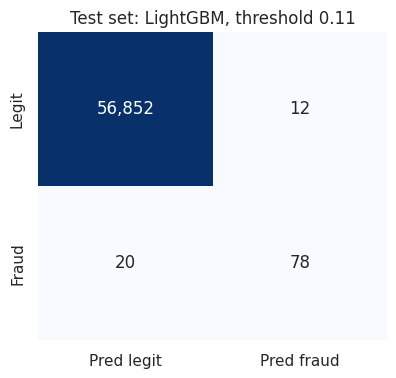

2026/09/26 16:07:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final run id: d3bfc81773b04177936ec000a2477e50


In [20]:
final_builder = candidates[FINAL_VARIANT][0]
final_pipeline = final_builder(clone(models[BEST_MODEL])).fit(X_train, y_train)

test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_metrics = evaluate(y_test, test_proba, FINAL_THRESHOLD)
test_default = evaluate(y_test, test_proba, 0.5)
y_test_arr = y_test.to_numpy()
amount_test = X_test["Amount"].to_numpy()
test_cost = business_cost(y_test_arr, test_proba, amount_test, FINAL_THRESHOLD)
fraud_value_test = amount_test[y_test_arr == 1].sum()
caught_value = amount_test[(y_test_arr == 1) & (test_proba >= FINAL_THRESHOLD)].sum()

display(pd.DataFrame({f"threshold {FINAL_THRESHOLD} (chosen)": test_metrics,
                      "threshold 0.5 (reference)": test_default}).T[metric_cols + ["tp", "fn", "fp", "tn"]])
print(f"Fraud value in test set: €{fraud_value_test:,.2f}; value caught: €{caught_value:,.2f} "
      f"({caught_value / fraud_value_test:.1%})")
print(f"Business cost on test (missed fraud + €{FP_COST:g} per false alarm): €{test_cost:,.2f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
cm = np.array([[test_metrics["tn"], test_metrics["fp"]], [test_metrics["fn"], test_metrics["tp"]]])
sns.heatmap(cm, annot=True, fmt=",d", cbar=False, cmap="Blues", ax=ax,
            xticklabels=["Pred legit", "Pred fraud"], yticklabels=["Legit", "Fraud"])
ax.set_title(f"Test set: {BEST_MODEL}, threshold {FINAL_THRESHOLD}")
plt.savefig(FIG_DIR / "final_test_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

final_run_id = log_run(
    run_name=f"FINAL - {BEST_MODEL} ({FINAL_VARIANT}) - test",
    pipeline=final_pipeline,
    metrics={**test_metrics, "business_cost_eur": test_cost,
             "fraud_value_caught_share": caught_value / fraud_value_test},
    params={"model_type": BEST_MODEL, "variant": FINAL_VARIANT, "threshold": FINAL_THRESHOLD,
            "fp_cost_eur": FP_COST, "trained_on": "full training set (80%)"},
    tags={"stage": "final_test"},
    figures={"final_test_confusion_matrix.png": fig},
    prefix="test_",
)
print("Final run id:", final_run_id)

**Test-set result (used once).** At the chosen threshold of 0.11, the model catches **78 of 98 frauds (recall 0.796)** with **12 false alarms among 56,864 legitimate transactions (precision 0.867)**. That is in line with cross-validation (recall 0.817, precision 0.897), so there is no sign of overfitting to the validation data. The lower threshold catches 2 more frauds than 0.5, at the price of 5 more false alarms.

**The most important finding is about value, not counts.** The model catches 80% of fraud *cases* but only **57% of fraud *value*** (€6,057 of €10,645). Five missed transactions between €520 and €1,810 account for **€4,296 of the €4,588 missed**. The model is good at the common pattern (many small, strongly anomalous transactions) and weaker on rarer, high-value fraud. Next steps: weight training examples by `Amount`, or add a rule that routes high-value transactions with moderate scores to manual review.

### 4.6 Explaining the model with SHAP
SHAP (SHapley Additive exPlanations) attributes each prediction to the features that pushed the fraud score up or down. I explain the final model on a sample of **5,000 random test transactions plus all 98 test fraud cases** (so fraud behaviour is visible in the plots). Values are in log-odds: positive = pushes towards "fraud".

In [21]:
import shap

model_step = final_pipeline.named_steps["model"]
X_test_scaled = final_pipeline.named_steps["scale_time_amount"].transform(X_test)

sample_idx = X_test_scaled.sample(5000, random_state=SEED).index.union(y_test[y_test == 1].index)
X_shap = X_test_scaled.loc[sample_idx]
explainer = shap.TreeExplainer(model_step)
shap_values = explainer(X_shap)
if shap_values.values.ndim == 3:        # some model types return one slice per class
    shap_values = shap_values[:, :, 1]

mean_abs = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
top5 = mean_abs.head(5).index.tolist()

# Direction: does a HIGH feature value push towards fraud or away from it?
direction = {
    f: np.corrcoef(X_shap[f], shap_values[:, f].values)[0, 1] for f in top5
}
y_shap = y_test.loc[sample_idx]
top5_table = pd.DataFrame({
    "mean_|SHAP|": mean_abs[top5],
    "effect": ["higher value → more fraud-like" if direction[f] > 0 else "lower value → more fraud-like" for f in top5],
    "median (legit)": [X_test.loc[sample_idx][f][y_shap == 0].median() for f in top5],
    "median (fraud)": [X_test.loc[sample_idx][f][y_shap == 1].median() for f in top5],
})
top5_table.index.name = "feature"
display(top5_table)
top5_table.to_csv(REPORT_DIR / "shap_top5_features.csv")

,mean_|SHAP|,effect,median (legit),median (fraud)
feature,,,,
V14,0.5268,lower value → more fraud-like,0.0579,-6.7746
V4,0.5237,higher value → more fraud-like,-0.0123,3.9539
V26,0.2411,lower value → more fraud-like,-0.0547,0.1152
V12,0.2039,lower value → more fraud-like,0.1336,-6.0148
Time,0.2004,lower value → more fraud-like,"84,171.0000","64,029.0000"


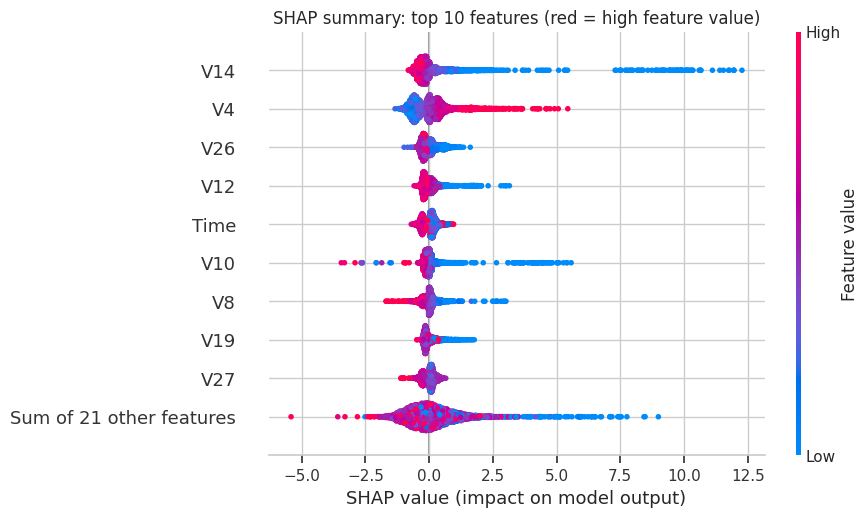

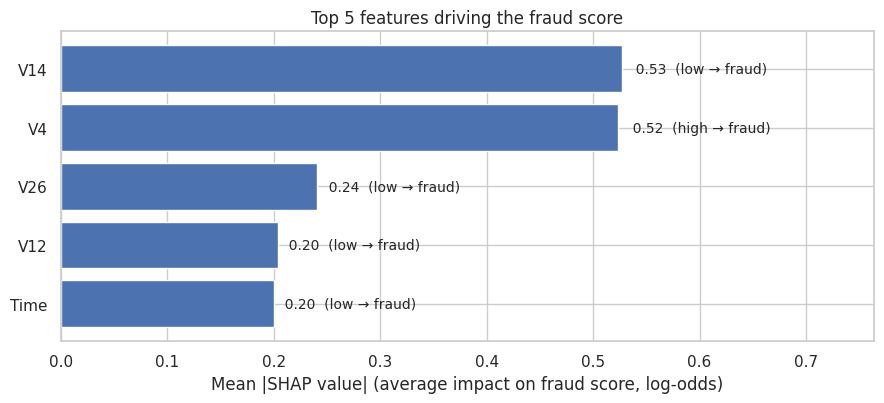

In [22]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("SHAP summary: top 10 features (red = high feature value)")
plt.savefig(FIG_DIR / "shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# Annotated top-5 importance chart
fig, ax = plt.subplots(figsize=(9, 4.2))
vals = mean_abs[top5][::-1]
ax.barh(vals.index, vals.values, color="#4c72b0")
for i, f in enumerate(vals.index):
    note = "high → fraud" if direction[f] > 0 else "low → fraud"
    ax.text(vals[f] * 1.01, i, f"  {vals[f]:.2f}  ({note})", va="center", fontsize=10)
ax.set(xlabel="Mean |SHAP value| (average impact on fraud score, log-odds)",
       title="Top 5 features driving the fraud score", xlim=(0, vals.max() * 1.45))
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_top5_annotated.png", dpi=120, bbox_inches="tight")
plt.show()

Transaction 77348: amount €0.01, fraud score 1.000


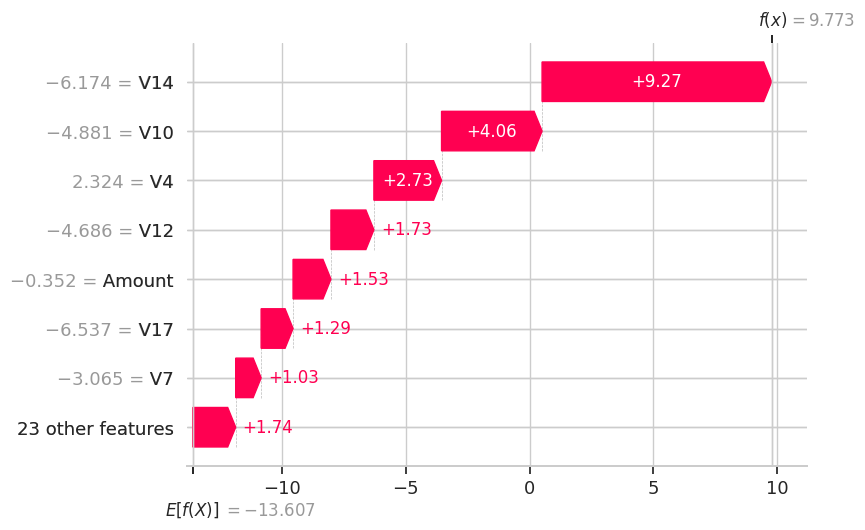

In [23]:
# One caught fraud case, explained feature by feature
fraud_scores = pd.Series(test_proba, index=X_test.index)
caught_fraud = fraud_scores[(y_test == 1) & (fraud_scores >= FINAL_THRESHOLD)].index.intersection(sample_idx)
example = caught_fraud[0]
pos = X_shap.index.get_loc(example)
print(f"Transaction {example}: amount €{X_test.loc[example, 'Amount']:.2f}, fraud score {fraud_scores[example]:.3f}")
plt.figure()
shap.plots.waterfall(shap_values[pos], max_display=8, show=False)
plt.savefig(FIG_DIR / "shap_waterfall_example.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=final_run_id):
    for f in ["shap_beeswarm.png", "shap_top5_annotated.png", "shap_waterfall_example.png"]:
        mlflow.log_artifact(str(FIG_DIR / f), artifact_path="shap")
    mlflow.log_artifact(str(REPORT_DIR / "shap_top5_features.csv"), artifact_path="shap")

### 4.7 What the top 5 features mean — plain-language summary
*Written for a non-technical reader, e.g. a fraud-operations manager or a compliance reviewer.*

The bank anonymised 28 of the 30 inputs (V1–V28) to protect cardholder privacy, so I cannot say "V14 is the merchant category". I *can* say how each signal behaves and how strongly the model relies on it.

| Rank | Feature | What the model has learned | How strong |
|---|---|---|---|
| 1 | **V14** | The single strongest warning sign. Legitimate transactions sit close to 0 (median 0.06); fraud is typically **far below** (median −6.8). A strongly negative V14 can on its own push a transaction into the "fraud" range. | Very strong |
| 2 | **V4** | The mirror image of V14: fraud tends to have **unusually high** V4 (median 4.0 vs about 0 for legitimate). The model looks for V14 and V4 moving in opposite directions together. | Very strong |
| 3 | **V26** | A weaker, supporting signal: low values nudge the score up slightly. It rarely decides a case alone. | Moderate |
| 4 | **V12** | Behaves like V14: fraud is typically **far below normal** (median −6.0 vs 0.13). It confirms what V14 already suggests. | Moderate |
| 5 | **Time** | Seconds since the start of the 48-hour data collection. The model picked up that fraud was relatively more common early in the window, including overnight when legitimate spending drops. | Moderate, **not reliable in production** |

**What this means in practice**
- The model's decisions are driven mainly by **a small number of strongly unusual patterns** (V14, V4, V12), not by transaction size. `Amount` is not in the top five: fraud here comes in all sizes, and many cases are very small.
- The waterfall chart shows a typical caught case: a **€0.01 transaction** scored 1.00, driven by extreme V14 and V4 values. Tiny charges like this are consistent with **card testing**, where fraudsters check whether a stolen card works before spending on it.
- **A flaw found through explainability:** `Time` should not be a top-five driver. It counts seconds from an arbitrary start point, so in production it only increases and never repeats. The model learned something specific to these two days. Before any real deployment, `Time` should be replaced by **hour of day** (or dropped) and the model retrained. This is recorded as a known failure mode in the Model Card.
- SHAP explains **what the model relies on**, not what causes fraud. Because the features are anonymised, a fraud analyst cannot yet use these explanations to justify a decision to a customer. In a real system, SHAP would be run on the original, named features.

## 5. Model Drift and Monitoring Readiness

### 5.1 Drift reports with Evidently AI
The dataset covers only two days, so there is no genuine "future" production data. I simulate two production scenarios and compare each against the **training distribution** (reference):

| Scenario | "Production" slice | Purpose |
|---|---|---|
| **A. Natural shift over time** | Test transactions from **day 2**, compared with training transactions from **day 1** | Realistic check: does behaviour change from one day to the next? |
| **B. Simulated shift** | Test set with injected changes: amounts +40% (e.g. holiday season or inflation), and a shift in V1–V4 for 30% of transactions (e.g. a new merchant mix or a change in an upstream data pipeline) | Shows what a drift alarm looks like and whether the model's score distribution reacts |

`Time` (seconds since the start of the data collection) is excluded, as it always increases in production and would always "drift". The model's **fraud score** is included as an extra column, so the report also detects **prediction drift**.

In [ ]:
from evidently import Report
from evidently.presets import DataDriftPreset

feature_cols = [c for c in X.columns if c != "Time"]

oof_reference = pd.Series(candidates[FINAL_VARIANT][1], index=X_train.index)


def with_score(frame, reference=False):
    out = frame[feature_cols].copy()
    out["fraud_score"] = (oof_reference.loc[frame.index].to_numpy() if reference
                          else final_pipeline.predict_proba(frame)[:, 1])
    return out


def drift_summary(snapshot):
    rows, share = [], None
    for m in snapshot.dict()["metrics"]:
        if m["metric_name"].startswith("DriftedColumnsCount"):
            share = m["value"]["share"]; count = m["value"]["count"]
        elif m["metric_name"].startswith("ValueDrift"):
            cfg = m["config"]
            rows.append({"column": cfg["column"], "method": cfg["method"], "score": m["value"],
                         "threshold": cfg["threshold"]})
    table = pd.DataFrame(rows).set_index("column")
    # Evidently reports a distance for Wasserstein/Jensen-Shannon (drift if >= threshold)
    # and a p-value for statistical tests (drift if < threshold)
    is_pvalue = table["method"].str.contains("p_value|test", case=False)
    table["drift_detected"] = np.where(is_pvalue, table["score"] < table["threshold"],
                                       table["score"] >= table["threshold"])
    return int(count), share, table.sort_values("score", ascending=False)


day1_train = X_train[X_train["Time"] < 86_400]
day2_test = X_test[X_test["Time"] >= 86_400]
reference = with_score(day1_train, reference=True)
current_a = with_score(day2_test)


def simulate_shift(frame, seed=SEED):
    rng = np.random.default_rng(seed)
    shifted = frame.copy()
    shifted["Amount"] = shifted["Amount"] * 1.4
    affected = rng.random(len(shifted)) < 0.30
    for col in ["V1", "V2", "V3", "V4"]:
        shifted.loc[affected, col] += 0.75 * X_train[col].std()
    return shifted


reference_full = with_score(X_train, reference=True)
current_b = with_score(simulate_shift(X_test))

drift_results = {}
for label, ref, cur, fname in [
    ("A. Day 1 (train) vs day 2 (test)", reference, current_a, "drift_report_A_day1_vs_day2.html"),
    ("B. Train vs simulated shifted production", reference_full, current_b, "drift_report_B_simulated_shift.html"),
]:
    snapshot = Report([DataDriftPreset()]).run(current_data=cur, reference_data=ref)
    snapshot.save_html(str(REPORT_DIR / fname))
    count, share, table = drift_summary(snapshot)
    drift_results[label] = table
    fs = table.loc["fraud_score"]
    top_drivers = [f for f in top5 if f in table.index]
    print(f"{label}: {count} of {len(table)} columns drifted ({share:.0%}) -> saved {REPORT_DIR / fname}")
    print(f"    prediction drift (fraud_score): distance {fs.score:.4f}, drift={bool(fs.drift_detected)}")
    print(f"    drifted among the model's top-5 SHAP features: "
          f"{[f for f in top_drivers if table.loc[f, 'drift_detected']]}")

A. Day 1 (train) vs day 2 (test): 22 of 30 columns drifted (73%) -> saved reports/drift_report_A_day1_vs_day2.html
    prediction drift (fraud_score): distance 0.0153, drift=False
    drifted among the model's top-5 SHAP features: ['V14', 'V4', 'V26']


B. Train vs simulated shifted production: 5 of 30 columns drifted (17%) -> saved reports/drift_report_B_simulated_shift.html
    prediction drift (fraud_score): distance 0.0027, drift=False
    drifted among the model's top-5 SHAP features: ['V4']


A. Day 1 (train) vs day 2 (test)


,method,score,threshold,drift_detected
column,,,,
V3,Wasserstein distance (normed),1.0913,0.1000,True
V25,Wasserstein distance (normed),0.6494,0.1000,True
V15,Wasserstein distance (normed),0.5090,0.1000,True
V5,Wasserstein distance (normed),0.4440,0.1000,True
V11,Wasserstein distance (normed),0.3993,0.1000,True
V22,Wasserstein distance (normed),0.3830,0.1000,True
V4,Wasserstein distance (normed),0.3002,0.1000,True
V1,Wasserstein distance (normed),0.2929,0.1000,True


B. Train vs simulated shifted production


,method,score,threshold,drift_detected
column,,,,
V2,Wasserstein distance (normed),0.2272,0.1000,True
V3,Wasserstein distance (normed),0.2265,0.1000,True
V4,Wasserstein distance (normed),0.2254,0.1000,True
V1,Wasserstein distance (normed),0.2231,0.1000,True
Amount,Wasserstein distance (normed),0.1459,0.1000,True
V12,Wasserstein distance (normed),0.0153,0.1000,False
V25,Wasserstein distance (normed),0.0107,0.1000,False
V16,Wasserstein distance (normed),0.0106,0.1000,False


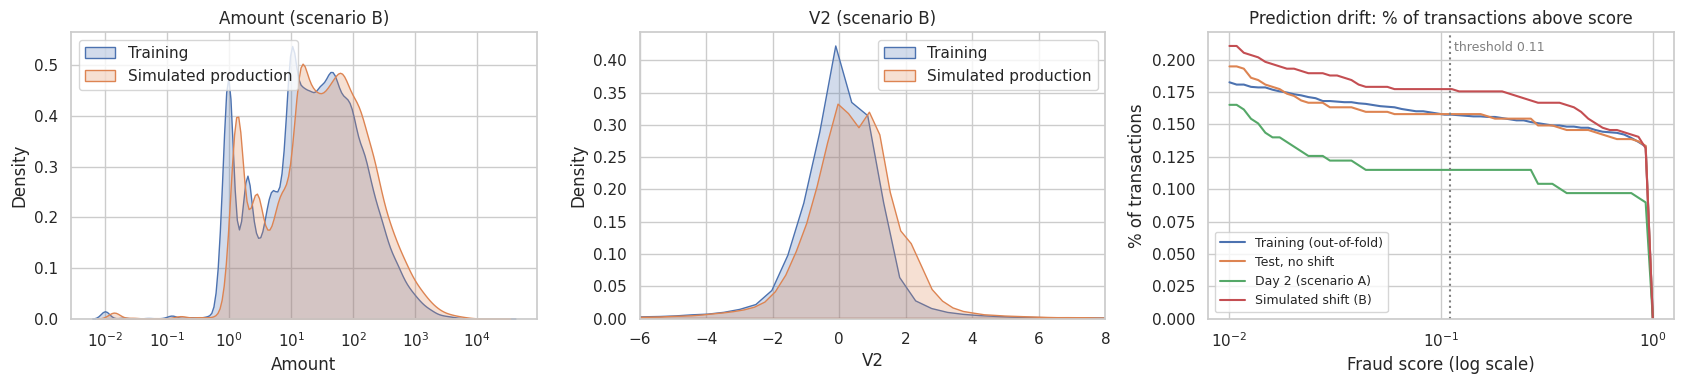

,transactions,fraud_rate_%,alert_rate_%,mean_score,recall,precision
slice,,,,,,
Test: day 1,29112,0.2233,0.1992,0.0019,0.8000,0.8966
Test: day 2 (scenario A),27850,0.1185,0.1149,0.0010,0.7879,0.8125
Test: all (no shift),56962,0.1720,0.1580,0.0015,0.7959,0.8667
Test: simulated shift (scenario B),56962,0.1720,0.1773,0.0016,0.7959,0.7723


In [ ]:
for label, table in drift_results.items():
    print(label)
    display(table.head(8))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.kdeplot(reference_full.loc[reference_full["Amount"] > 0, "Amount"], ax=axes[0], label="Training", log_scale=True, fill=True)
sns.kdeplot(current_b.loc[current_b["Amount"] > 0, "Amount"], ax=axes[0], label="Simulated production", log_scale=True, fill=True)
axes[0].set(title="Amount (scenario B)"); axes[0].legend()
sns.kdeplot(reference_full["V2"], ax=axes[1], label="Training", fill=True)
sns.kdeplot(current_b["V2"], ax=axes[1], label="Simulated production", fill=True)
axes[1].set(title="V2 (scenario B)", xlim=(-6, 8)); axes[1].legend()
# Prediction drift: share of transactions scoring above each threshold (size-normalised)
score_grid = np.logspace(-2, 0, 60)
for lbl, scores in [("Training (out-of-fold)", reference_full["fraud_score"]),
                    ("Test, no shift", with_score(X_test)["fraud_score"]),
                    ("Day 2 (scenario A)", current_a["fraud_score"]),
                    ("Simulated shift (B)", current_b["fraud_score"])]:
    s = np.asarray(scores)
    axes[2].plot(score_grid, [(s >= t).mean() * 100 for t in score_grid], label=lbl)
axes[2].axvline(FINAL_THRESHOLD, ls=":", c="grey")
axes[2].text(FINAL_THRESHOLD * 1.05, 0.97, f"threshold {FINAL_THRESHOLD}", va="top", fontsize=9,
             color="grey", transform=axes[2].get_xaxis_transform())
axes[2].set(xscale="log", ylim=(0, None), title="Prediction drift: % of transactions above score",
            xlabel="Fraud score (log scale)", ylabel="% of transactions")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "drift_overview.png", dpi=120, bbox_inches="tight")
plt.show()

shifted_test = simulate_shift(X_test)
slices = {
    "Test: day 1": (X_test[X_test["Time"] < 86_400], y_test[X_test["Time"] < 86_400]),
    "Test: day 2 (scenario A)": (day2_test, y_test.loc[day2_test.index]),
    "Test: all (no shift)": (X_test, y_test),
    "Test: simulated shift (scenario B)": (shifted_test, y_test),
}
slice_rows = []
for label, (Xs, ys) in slices.items():
    proba = final_pipeline.predict_proba(Xs)[:, 1]
    m = evaluate(ys, proba, FINAL_THRESHOLD)
    slice_rows.append({"slice": label, "transactions": len(ys), "fraud_rate_%": ys.mean() * 100,
                       "alert_rate_%": (proba >= FINAL_THRESHOLD).mean() * 100,
                       "mean_score": proba.mean(), "recall": m["recall"], "precision": m["precision"]})
slice_table = pd.DataFrame(slice_rows).set_index("slice")
display(slice_table)
slice_table.to_csv(REPORT_DIR / "drift_slice_performance.csv")

with mlflow.start_run(run_id=final_run_id):
    for f in REPORT_DIR.glob("drift_report_*.html"):
        mlflow.log_artifact(str(f), artifact_path="drift")
    mlflow.log_artifact(str(FIG_DIR / "drift_overview.png"), artifact_path="drift")

### 5.2 Drift findings
| | Scenario A: day 1 → day 2 | Scenario B: simulated shift |
|---|---|---|
| Columns flagged by Evidently | **22 of 30 (73%)**, largest V3, V25, V15 | **5 of 30 (17%)**: exactly the injected V1–V4 and `Amount` |
| Top-5 SHAP drivers flagged | V14, V4, V26 | V4 |
| Evidently distance on `fraud_score` | 0.015 (no drift) | 0.003 (no drift) |
| Alert rate | 0.199% → **0.115%** (day 1 → day 2 test) | 0.158% → **0.177%** (+12%) |
| Recall (labels known in simulation) | 0.800 → 0.788 (26 of 33 day-2 frauds) | 0.796 → 0.796 (unchanged) |
| Precision | 0.897 → 0.813 | 0.867 → **0.772** (false alarms 12 → 23) |

**Scenario A: a lot of drift, little harm.** Evidently flags almost three quarters of the columns, including three of the model's top drivers. Yet recall barely moves. The fall in alert rate mirrors a fall in the **fraud rate itself** (0.22% → 0.12%): fewer frauds on day 2, not a blind model. Two lessons follow. First, Wasserstein distance with a 0.1 threshold on 28,000 rows is very sensitive, and normal day-to-day and time-of-day variation in spending is enough to trigger it. Second, "73% of columns drifted" would have been a **false alarm** as a retraining trigger. Drift has to be read together with feature importance and, eventually, performance.

**Scenario B: drift detection works, and prediction drift hides in the tail.** Evidently found exactly the five injected columns and no others. The model still caught the same 78 of 98 frauds, but **false alarms almost doubled** (12 → 23). The shift made some legitimate transactions look more like fraud through V4, a top driver. Evidently's whole-distribution distance on the fraud score did **not** flag this: 99.8% of scores are close to zero, so a change affecting a few hundred high scores hardly moves the distribution. The alert rate and the share of scores above the threshold (right-hand chart) show the change clearly. **Prediction drift should be monitored on the tail of the score distribution, not on the whole distribution.**

The full interactive reports are saved as `reports/drift_report_A_day1_vs_day2.html` and `reports/drift_report_B_simulated_shift.html`, and logged to the final MLflow run.

### 5.3 What drift means in fraud detection, and how to respond

**Drift** is any change between the data a model was trained on and the data it sees in production. In fraud detection it is not an occasional nuisance but the normal state of affairs, for three reasons:

1. **Data drift (covariate shift)** — the mix of legitimate transactions changes: seasonal spending (holidays, sales events), new merchants and payment channels, new customer segments, inflation in transaction amounts, or a change in an upstream system that alters how a feature is computed.
2. **Concept drift** — the relationship between features and fraud changes. Fraud is **adversarial**: once a pattern is blocked, fraudsters change tactics (smaller amounts, different merchants, new card-testing schemes). A transaction profile that meant "safe" last quarter can mean "fraud" this quarter, even if the input distributions look unchanged.
3. **Label drift and label delay** — the fraud rate itself changes (e.g. an attack campaign), and true labels arrive late: a fraud is often confirmed only when the cardholder disputes a charge weeks later. Recall therefore cannot be measured in real time; input and prediction drift act as the **early warning**, and confirmed labels provide the **ground truth** later.

**How I would respond in a real deployment**

| Stage | Action |
|---|---|
| **Detect** | Run a drift report like the one above daily on a rolling window (e.g. last 7 days vs training reference). Track the alert rate and fraud-score distribution hourly. |
| **Triage** | Establish whether the change is a data-pipeline problem (missing values, unit or schema change — fix the pipeline, not the model), a benign business change (seasonality — monitor), or a genuine change in fraud behaviour (act). Check which features drifted and whether they are among the model's top SHAP drivers; drift in V4 or V14 matters far more than drift in V25. |
| **Mitigate quickly** | Adjust the decision threshold to keep the analyst alert volume manageable; add temporary rules for a new attack pattern; route borderline cases to manual review. |
| **Retrain** | Retrain on recent labelled data (including newly confirmed fraud and chargebacks), validate on the most recent time period (**out-of-time validation**, not a random split), and compare against the current model in MLflow. |
| **Release safely** | Deploy as a **shadow or champion–challenger** model first, compare live alert rates and confirmed-fraud capture, then promote. Document the change in the Model Card. |

### 5.4 Monitoring signals that trigger retraining

Signals are listed from fastest (available the moment a transaction is scored) to slowest (needs confirmed fraud labels). Trigger levels are starting points taken from this project's results, to be recalibrated on real traffic.

| # | Signal | Why it matters | Baseline here | Suggested trigger |
|---|---|---|---|---|
| 1 | **Alert rate**: share of transactions flagged | Available instantly; a jump means the model or the traffic has changed, and it directly drives analyst workload | 0.16% of test transactions | 7-day average outside **0.08%–0.32%** (half or double the baseline) |
| 2 | **Score-tail drift**: share of transactions scoring above a low "watch" level (e.g. 0.01) and the top-percentile scores | Catches a change in what the model "sees" before labels arrive. Section 5.2 showed that a whole-distribution distance misses it | 0.19% of test transactions score ≥ 0.01 | Week-over-week change > 25% |
| 3 | **Drift in the model's key features**: V14, V4, V12, V26 and `Amount` | Drift in a top SHAP driver matters far more than drift in an unused column. Scenario A showed that "22 of 30 columns drifted" can be a **false alarm** | Training distribution | Drift detected on **any top-5 SHAP feature** for 3 consecutive days |
| 4 | **Recall on confirmed fraud** (chargebacks and investigations) | The true measure of missed fraud; arrives with weeks of delay | 0.80 on test | Rolling 30-day recall **< 0.72** (below the lower bound of the bootstrap interval) |
| 5 | **Precision of alerts** (share of alerts confirmed as fraud) | Measures wasted analyst time; available within days | 0.87 on test | Rolling 30-day precision **< 0.75** |
| 6 | **Business cost** per 10,000 transactions (missed fraud value + review cost) | Combines both error types in money | €816 per 10,000 test transactions | 30% above baseline for a month |
| 7 | **Data quality**: missing values, schema changes, share of €0 amounts | Many "drift" alarms are really broken pipelines | 0 missing values | Any schema change or missing values > 0.1% |

**Retraining policy.** Retrain on a fixed schedule (e.g. monthly, with the newest confirmed labels) **and** whenever signal 4, 5 or 6 fires. Signals 1–3 trigger an **investigation**, not automatic retraining, since a seasonal shift without a performance drop does not need a new model. Every retrained model is validated out-of-time, compared with the current model in MLflow, and released through shadow mode.

## 6. Summary and Next Steps

**Final model:** LightGBM (200 trees, `reg_lambda=1.0`), trained on the raw imbalanced data without SMOTE, with `Time` and `Amount` standardised and a cost-optimised decision threshold of **0.11**.

| Test set (56,962 transactions, 98 fraud, used once) | Value |
|---|---|
| Recall (fraud caught) | **0.796** (78 of 98) |
| Precision (alerts that are fraud) | **0.867** (12 false alarms) |
| F1 | 0.830 |
| AUC-ROC / average precision | 0.974 / 0.860 |
| Fraud value caught | 57% (€6,057 of €10,645) |

**Key findings**
1. **Accuracy is meaningless here**: predicting "never fraud" scores 99.83%. Recall, precision and cost carry the evaluation.
2. **Default gradient-boosting settings can silently fail on extreme imbalance.** Default LightGBM scored AUC 0.51 in the first version; one standard regularisation setting fixed it and made it the best model.
3. **The top three tree models are statistically tied on recall** (cross-validated 0.774–0.787). The final choice depends on the false-alarm cost, which is an assumption and should be confirmed with the business.
4. **SMOTE did not improve the model's ability to rank fraud**; it moved the operating point. Tuning the threshold achieves the same trade-off more simply.
5. **The model catches small, anomalous fraud well and misses large fraud more often**: 5 missed transactions account for 94% of the missed value.
6. **SHAP exposed a production risk**: `Time` (seconds since data collection began) is a top-five driver and must be replaced before deployment.
7. **Drift monitoring must be interpreted, not automated blindly**: 73% of columns drifted from day 1 to day 2 with no loss of recall, while a small targeted shift doubled false alarms without moving the overall score distribution.

**Next steps:** replace `Time` with hour of day; weight training by transaction amount; tune hyperparameters with cross-validation; confirm the false-alarm cost and re-test XGBoost as a challenger; validate out-of-time on newer data.

**Project documents:** [Model Card](MODEL_CARD.md) · [README](README.md) · MLflow runs: `mlflow ui --backend-store-uri sqlite:///mlflow.db` · summary: `reports/mlflow_runs_summary.csv`

In [26]:
# Export all MLflow runs to a CSV so the results can be read without starting the MLflow UI
runs = mlflow.search_runs(experiment_names=[EXPERIMENT])
keep = ["run_id", "tags.mlflow.runName", "tags.stage", "params.model_type", "params.resampling",
        "params.threshold"] + sorted(c for c in runs.columns if c.startswith("metrics."))
runs[[c for c in keep if c in runs.columns]].sort_values("tags.mlflow.runName").to_csv(
    REPORT_DIR / "mlflow_runs_summary.csv", index=False)
print(f"{len(runs)} MLflow runs exported to {REPORT_DIR / 'mlflow_runs_summary.csv'}")

8 MLflow runs exported to reports/mlflow_runs_summary.csv
